In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import sparse, linalg
from scipy.io import loadmat,savemat
from math import factorial

from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture # jaxxx??? # Hyakkk
from sklearn.decomposition import SparsePCA
# from scipy.io import loadmat
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import matplotlib.colors as colors
from scipy.interpolate import RegularGridInterpolator

# Seaborn colormap
import seaborn as sns
import colorcet as cc
sns_list = sns.color_palette(cc.glasbey,n_colors=20).as_hex()

# sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)
cm = sns_cmap

sns_list_balance_models = sns_list.copy()

sns_list_balance_models.insert(0, '#ffffff')  # Insert white at zero position
sns_list_balance_models.pop(1)
sns_cmap_balance_models = ListedColormap(sns_list_balance_models)

cm_balance_models = sns_cmap_balance_models
  
mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']

In [3]:
labels = [r'$\bar{v} \bar{u}_y$', r'$\bar{w}\bar{u}_z$',
        r'$\nu \bar{u}_{yy}$', r'$\nu \bar{u}_{zz}$',
        r'$\overline{({u^\prime v^\prime})}_y$', r'$\overline{(u^\prime w^\prime)}_z$']

In [4]:
load_dir = 'data/grid_spacing_0.025_TF_5/support_x_0.2_support_y_0.2/'

nc =9

trial = 0

cluster_idx = np.load(load_dir + f'nc{nc}/trial_{trial}/cluster_idx.npy')
masked_x_coords_DNS_grid = np.load(load_dir + 'terms/masked_x_coords_DNS_grid.npy')
masked_y_coords_DNS_grid = np.load(load_dir + 'terms/masked_y_coords_DNS_grid.npy')

# also load features
features = np.load(load_dir + 'terms/features.npy')
nfeatures = 6

In [5]:
x_plot = np.load(load_dir + 'terms/masked_x_coords_DNS_grid.npy')
y_plot = np.load(load_dir + 'terms/masked_y_coords_DNS_grid.npy')

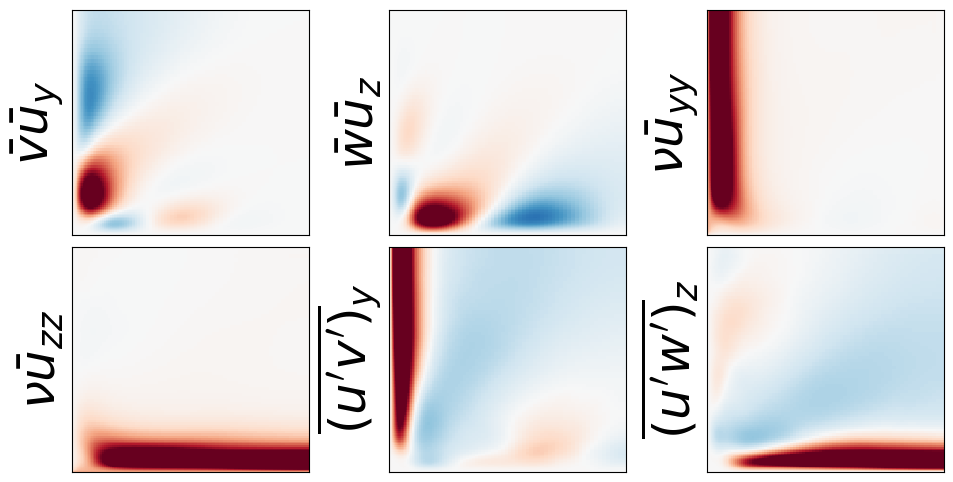

In [7]:
# Plot all six terms in the RANS equation
plt.figure(figsize=(11.25, 6))
# labels = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$', r'$\rho^{-1} \bar{p}_x$',
#           r'$\nu \nabla^2 \bar{u}$', r'$\overline{(u^\prime v^\prime)}_y$', r'$\overline{({u^\prime} ^2)}_x$']
clim = 8e-2
fontsize=36

plt.subplot(231)
field = np.reshape(features[:,0], x_plot.shape)
plt.pcolormesh(x_plot, y_plot, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[0], fontsize=fontsize)

plt.subplot(232)
field = np.reshape(features[:,1], x_plot.shape)
plt.pcolormesh(x_plot, y_plot, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[1], fontsize=fontsize)

plt.subplot(233)
field = np.reshape(features[:,2], x_plot.shape)
plt.pcolormesh(x_plot, y_plot, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[2], fontsize=fontsize)

plt.subplot(234)
field = np.reshape(features[:,3], x_plot.shape)
plt.pcolormesh(x_plot, y_plot, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[3], fontsize=fontsize)

plt.subplot(235)
field = np.reshape(features[:,4], x_plot.shape)
plt.pcolormesh(x_plot, y_plot, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[4], fontsize=fontsize)

plt.subplot(236)
field = np.reshape(features[:,5], x_plot.shape)
plt.pcolormesh(x_plot, y_plot, field, vmin=-clim, vmax=clim, cmap='RdBu')
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.ylabel(labels[5], fontsize=fontsize)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.34, hspace=0.05)

plt.savefig('RANSDuct_WeakTerms.png', transparent=True,dpi=720)#,bbox_inches='tight'

plt.show()